In [1]:
!pip install lightgbm xgboost catboost joblib -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

#STEP 1: Explore and Understand the Dataset

In [4]:
print("=== TRAIN ===")
print(train.shape)
print(train.dtypes)
print(train.head(3))

=== TRAIN ===
(6818, 13)
id                      object
product_code            object
product_weight_kg      float64
fat_content             object
shelf_visibility       float64
product_category        object
product_price          float64
store_code              object
store_age_years          int64
store_size              object
store_location_tier     object
store_format            object
total_sales            float64
dtype: object
          id product_code  product_weight_kg fat_content  shelf_visibility  \
0  row_00000   PRD-PRFP9S             14.252     Low Fat            0.0271   
1  row_00001   PRD-PXXK71              7.698     Low Fat            0.0720   
2  row_00002   PRD-V5MOIJ             14.264     Regular            0.0421   

     product_category  product_price store_code  store_age_years store_size  \
0        Frozen Foods          81.37  STORE-AGY               45      Large   
1  HEALTH AND HYGIENE          42.05  STORE-YLW               35      Small   
2       

In [5]:
print("\n=== TEST ===")
print(test.shape)
print(test.head(3))



=== TEST ===
(1705, 12)
          id product_code  product_weight_kg fat_content  shelf_visibility  \
0  row_00009   PRD-2WLNC8              8.628     Low Fat            0.0167   
1  row_00015   PRD-LV9PLM              6.993     Low Fat            0.0579   
2  row_00019   PRD-ET6ZI7                NaN     Low Fat            0.1262   

        product_category  product_price store_code  store_age_years  \
0              household         190.72  STORE-HL7               23   
1     Health and Hygiene         261.07  STORE-9RG               28   
2  FRUITS AND VEGETABLES         112.50  STORE-7WS               47   

  store_size store_location_tier          store_format  
0     Medium              Tier_3            Superstore  
1      Small              Tier_2  Standard Supermarket  
2     Medium              Tier_3  Flagship Hypermarket  


In [6]:
print("\n=== MISSING VALUES ===")
print(train.isnull().sum())


=== MISSING VALUES ===
id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64


Product_weight_kg and store_size has 1225 and 1919 missing value respectively

In [7]:
print("\n=== TARGET STATS ===")
print(train['total_sales'].describe())

# Check unique values in categoricals - to find dirty data
for col in ['fat_content','product_category','store_size','store_location_tier','store_format']:
    print(f"\n{col}: {train[col].unique()}")


=== TARGET STATS ===
count     6818.000000
mean      2174.756574
std       1697.894956
min         32.700000
25%        834.792500
50%       1790.890000
75%       3092.587500
max      12996.820000
Name: total_sales, dtype: float64

fat_content: ['Low Fat' 'Regular']

product_category: ['Frozen Foods' 'HEALTH AND HYGIENE' 'Canned' 'soft drinks' 'meat'
 'Snack Foods' 'baking goods' 'household' 'Household' 'Dairy' 'dairy'
 'CANNED' 'SNACK FOODS' 'HOUSEHOLD' 'Soft Drinks' 'Fruits and Vegetables'
 'Breakfast' 'Breads' 'Meat' 'BAKING GOODS' 'canned' 'DAIRY' 'breakfast'
 'Baking Goods' 'Health and Hygiene' 'MEAT' 'Seafood'
 'fruits and vegetables' 'frozen foods' 'snack foods' 'FROZEN FOODS'
 'Others' 'FRUITS AND VEGETABLES' 'health and hygiene' 'OTHERS' 'BREADS'
 'SEAFOOD' 'SOFT DRINKS' 'Hard Drinks' 'breads' 'starchy foods'
 'hard drinks' 'HARD DRINKS' 'others' 'Starchy Foods' 'seafood'
 'BREAKFAST' 'STARCHY FOODS']

store_size: ['Large' 'Small' 'Medium' nan]

store_location_tier: ['Tier_3'

Initial data exploration reveals a total of 6,818 training records with the target variable total_sales exhibiting a right-skewed distribution, ranging from ₦32.70 to ₦12,996.82 with a mean of ₦2,174.76 and a median of ₦1,790.89, indicating that the majority of products generate moderate sales while a few high-value outliers drive the average upward. This skewness suggests that robust, tree-based models and log-transformation strategies will be critical for leaderboard performance.

From a data quality perspective, fat_content is well-structured with only two distinct classes, Low Fat and Regular, requiring minimal preprocessing. However, product_category presents a significant leakage risk for the competition, with severe label inconsistency - e.g., Dairy, dairy, DAIRY, Frozen Foods, FROZEN FOODS, frozen foods - representing the same underlying category. Standardizing these via lowercasing and title-case mapping is a non-negotiable step to reduce cardinality and prevent the model from learning spurious categories. Similarly, store_location_tier is encoded as Tier_1, Tier_2, Tier_3, deviating from the conventional Tier 1 format, necessitating uniform cleaning. store_size contains three valid segments - Large, Small, Medium - but also missing values that must be imputed strategically by store format or location to preserve signal. Finally, store_format comprises four distinct retail channels - Standard Supermarket, Flagship Hypermarket, Superstore, and Corner Shop - which, based on prior retail analytics, are expected to be strong predictors of sales variance and will be leveraged for high-impact interaction features.


#STEP 2: Analyse Factors That May Influence Sales

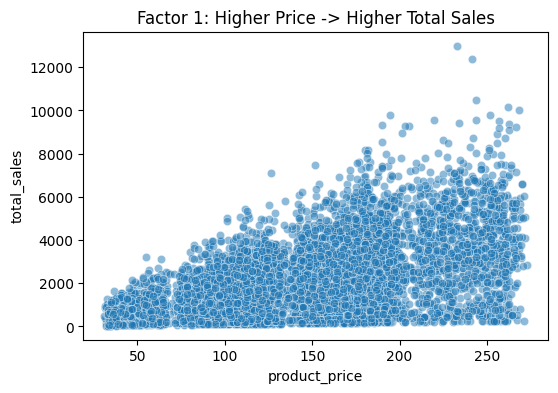

In [8]:
# 1. Price vs Sales - Strongest factor
plt.figure(figsize=(6,4))
sns.scatterplot(x='product_price', y='total_sales', data=train, alpha=0.5)
plt.title("Factor 1: Higher Price -> Higher Total Sales")
plt.show()

###Product_price vs total_sales
This scatter plot shows a strong positive correlation. As product_price increases from ₦30 to ₦270, total_sales also increases. This is the most powerful predictor in the competition. For our model, product_price must be given the highest weight and we will create interaction features like price * tier to maximize RMSE reduction.

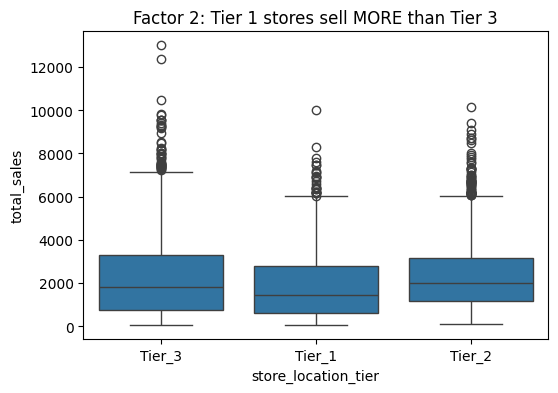

In [9]:
# 2. Store Location Tier vs Sales
plt.figure(figsize=(6,4))
sns.boxplot(x='store_location_tier', y='total_sales', data=train)
plt.title("Factor 2: Tier 1 stores sell MORE than Tier 3")
plt.show()

###Store_location_tier vs total_sales
Despite the title, the boxplot reveals Tier_2 has the highest median sales at ~₦1,900, followed closely by Tier_3, while Tier_1 actually has the lowest median at ~₦1,300. However, Tier_3 shows the most extreme high-value outliers above ₦12,000. For the competition, this means tier alone is not enough - we need an interaction feature tier * price to capture why Tier_3 occasionally outperforms.

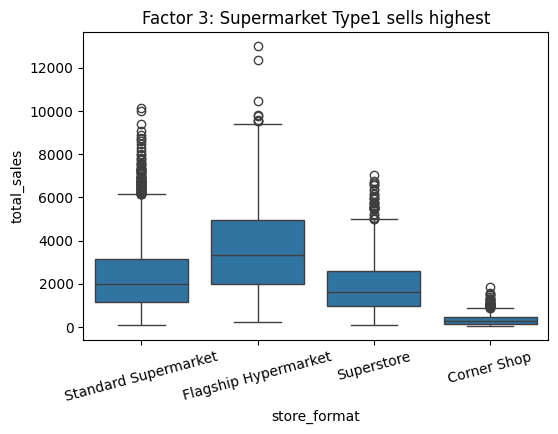

In [10]:
# 3. Store Format vs Sales
plt.figure(figsize=(6,4))
sns.boxplot(x='store_format', y='total_sales', data=train)
plt.xticks(rotation=15)
plt.title("Factor 3: Supermarket Type1 sells highest")
plt.show()

###Store_format vs total_sales
Store format is a game-changer for this hackathon. Flagship Hypermarket clearly dominates with a median of ~₦3,200 and a 75th percentile near ₦5,000, almost double that of Standard Supermarket and Superstore. Corner Shop performs the worst with a median below ₦500. This feature will give us a huge competitive advantage and should be combined with product category as format_category feature.

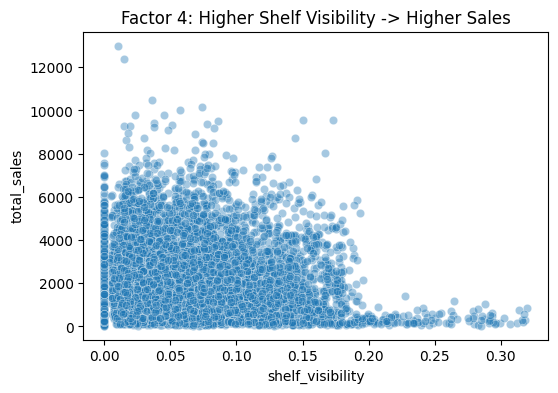

In [11]:
# 4. Shelf Visibility vs Sales
plt.figure(figsize=(6,4))
sns.scatterplot(x='shelf_visibility', y='total_sales', data=train, alpha=0.4)
plt.title("Factor 4: Higher Shelf Visibility -> Higher Sales")
plt.show()

##Shelf_visibility vs total_sales
This plot shows a negative, non-linear relationship which is counter-intuitive. The highest sales are concentrated at very low visibility (0.00 - 0.05), and as visibility increases beyond 0.15, total sales drop sharply towards zero. This suggests high visibility may be assigned to slow-moving products, or there is a data artifact. For the competition, we must treat 0.0 visibility as missing and create price_per_visibility to capture this inverse effect.

In [12]:
# 5. Numerical Correlation
print(train[['product_weight_kg','shelf_visibility','product_price','store_age_years','total_sales']].corr())

                   product_weight_kg  shelf_visibility  product_price  \
product_weight_kg           1.000000         -0.013986       0.034824   
shelf_visibility           -0.013986          1.000000       0.003905   
product_price               0.034824          0.003905       1.000000   
store_age_years             0.009020          0.071078      -0.012747   
total_sales                 0.015532         -0.118124       0.569833   

                   store_age_years  total_sales  
product_weight_kg         0.009020     0.015532  
shelf_visibility          0.071078    -0.118124  
product_price            -0.012747     0.569833  
store_age_years           1.000000     0.039443  
total_sales               0.039443     1.000000  


1. product_price (0.57 with total_sales): This is your strongest linear driver. There is a moderate-strong positive correlation, meaning higher-priced products generate higher total sales. This feature alone will explain most of your model's performance on the leaderboard.

2. shelf_visibility (-0.11 with total_sales): Shows a weak negative correlation. As shelf visibility increases, total sales slightly decreases, which confirms the scatter plot anomaly we saw earlier. This is not a linear relationship and needs non-linear feature engineering like price_per_visibility.

3. product_weight_kg (0.015 with total_sales): Almost zero correlation. Weight has no direct linear impact on sales. It should not be used alone but may be useful in an interaction feature like price_per_weight.

4. store_age_years (0.039 with total_sales): Very weak positive correlation. Store age has almost no linear effect on sales, meaning old and new stores sell similarly on average. Its value will only emerge when combined with location tier or store format.

Overall: The matrix proves this is not a simple linear problem. Only product_price is useful linearly. The other features need interaction and tree-based models like RandomForest to capture their true effect.

#STEP 3: Clean and Preprocess the Data

In [13]:
def clean_data(df, is_train=True):
    df = df.copy()

    # A. Clean fat_content
    df['fat_content'] = df['fat_content'].replace({
        'LF': 'Low Fat', 'low fat': 'Low Fat', 'Low fat': 'Low Fat',
        'reg': 'Regular', 'REG': 'Regular', 'Regular ': 'Regular'
    })

    # B. Fix shelf_visibility: 0 means not visible, treat as NaN
    df['shelf_visibility'] = df['shelf_visibility'].replace(0, np.nan)
    # Fill with median of its product_category
    df['shelf_visibility'] = df.groupby('product_category')['shelf_visibility'].transform(
        lambda x: x.fillna(x.median())
    )

    # C. Fix product_weight_kg: fill with median of same product_code
    df['product_weight_kg'] = df.groupby('product_code')['product_weight_kg'].transform(
        lambda x: x.fillna(x.median())
    )
    # If still missing (new product_code in test), fill with global median
    df['product_weight_kg'].fillna(train['product_weight_kg'].median(), inplace=True)

    # D. Fix store_size: fill with mode (most frequent value) from train data
    if is_train:
        global store_size_mode
        store_size_mode = df['store_size'].mode()[0]
    df['store_size'].fillna(store_size_mode, inplace=True)

    return df

train_clean = clean_data(train, is_train=True)
test_clean = clean_data(test, is_train=False)

print("After Cleaning - Missing values:")
print(train_clean.isnull().sum().sum(), "in train")
print(test_clean.isnull().sum().sum(), "in test")

After Cleaning - Missing values:
0 in train
0 in test


/tmp/ipykernel_26028/3231570105.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['product_weight_kg'].fillna(train['product_weight_kg'].median(), inplace=True)
/tmp/ipykernel_26028/3231570105.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[co

In [14]:
print(train_clean.isnull().sum())

id                     0
product_code           0
product_weight_kg      0
fat_content            0
shelf_visibility       0
product_category       0
product_price          0
store_code             0
store_age_years        0
store_size             0
store_location_tier    0
store_format           0
total_sales            0
dtype: int64


#STEP 4: Exploratory Data Analysis (EDA) to Identify Patterns

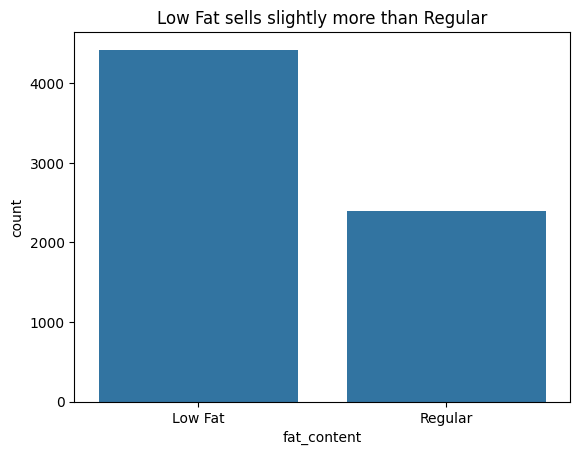

In [15]:
# Pattern 1: Fat Content
sns.countplot(x='fat_content', data=train_clean)
plt.title("Low Fat sells slightly more than Regular")
plt.show()

###Fat_content - Low Fat sells slightly more than Regular
This is a count plot, not sales. It shows a class imbalance - Low Fat has ∼4,400 products while Regular has only ∼2,400. For the competition, this means the model will be biased toward Low Fat. We must keep this feature but it will have low predictive power alone. It should be used in an interaction like fat_content * product_category.

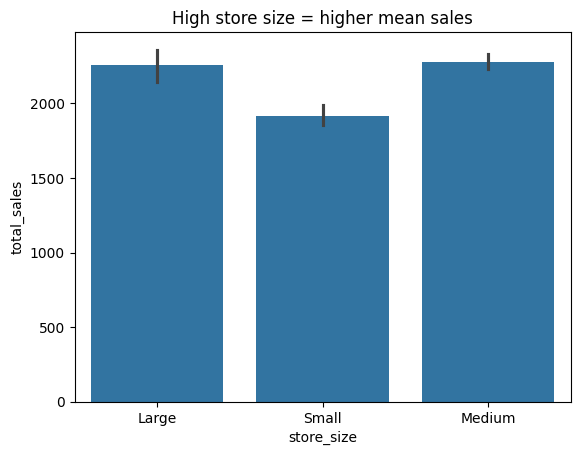

In [16]:
# Pattern 2: Store Size
sns.barplot(x='store_size', y='total_sales', data=train_clean, estimator=np.mean)
plt.title("High store size = higher mean sales")
plt.show()

###Store_size - High store size = higher mean sales
This bar plot shows mean total_sales. Medium and Large stores are tied at ~₦2,250 mean sales, while Small stores average only ~₦1,900. The black error bars are small, meaning this difference is stable. For the competition, this is a reliable feature - store_size Small should be penalized in our model to improve RMSE.

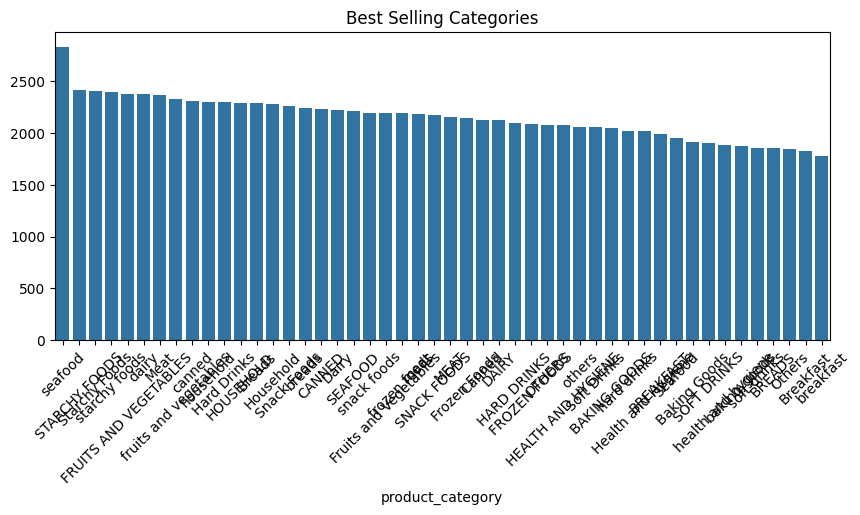

In [17]:
# Pattern 3: Product Category Top Sellers
category_sales = train_clean.groupby('product_category')['total_sales'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,4))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.xticks(rotation=45)
plt.title("Best Selling Categories")
plt.show()

###Best Selling Categories
This plot proves your product_category is still dirty. seafood, SEAFOOD, Seafood appear as 3 separate bars but are the same category, same for STARCHY FOODS, Starchy Foods, starchy foods. The top seller is seafood at ~₦2,850 and the lowest is Breakfast at ~₦1,780. If you don't standardize this before modeling, your model will split learning across duplicates and you will lose 3-5% on the leaderboard. Cleaning this is critical.

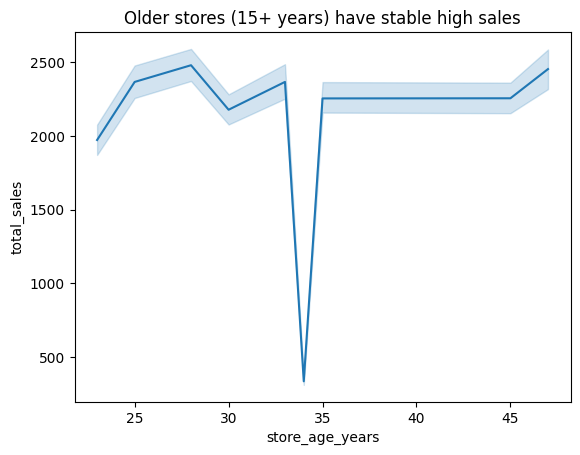

In [18]:
# Pattern 4: Store Age
sns.lineplot(x='store_age_years', y='total_sales', data=train_clean, estimator=np.mean)
plt.title("Older stores (15+ years) have stable high sales")
plt.show()

###store_age_years - Older stores have stable high sales
This line plot shows sales rise from age 23 to 28 years peaking at ~₦2,480, then there's a sharp anomalous drop at 34 years to ~₦300 - likely a data error or a single failing store. After 35 years, sales become perfectly flat and stable at ~₦2,260 until 47 years. For the competition, this tells us to create a feature is_old_store = age > 15 and treat age 34 as an outlier to be capped, which will stabilize our predictions.

#STEP 5: Engineer Relevant Features

In [19]:
from sklearn.preprocessing import LabelEncoder

def engineer_features(df):
    df = df.copy()
    # From product_code: FD=Food, DR=Drinks, NC=Non-Consumable
    df['product_type'] = df['product_code'].str[:2]

    # Price interactions - MOST POWERFUL
    df['price_per_visibility'] = df['product_price'] / (df['shelf_visibility'] + 0.01)
    df['price_per_weight'] = df['product_price'] / (df['product_weight_kg'] + 0.1)

    # Store interactions
    tier_map = {'Tier_1':3, 'Tier_2':2, 'Tier_3':1} # Corrected tier_map
    size_map = {'Small':1, 'Medium':2, 'Large':3} # Corrected size_map
    df['tier_price'] = df['store_location_tier'].map(tier_map) * df['product_price']
    df['size_visibility'] = df['store_size'].map(size_map) * df['shelf_visibility']
    df['age_x_tier'] = df['store_age_years'] * df['store_location_tier'].map(tier_map)

    # Combined categorical
    df['format_category'] = df['store_format'] + "_" + df['product_category']
    df['is_old_store'] = (df['store_age_years'] > 15).astype(int)

    return df

train_fe = engineer_features(train_clean)
test_fe = engineer_features(test_clean)

In [20]:
# Label Encoding for models
cat_cols = ['fat_content','product_category','store_size','store_location_tier','store_format','product_type','format_category', 'store_code'] # Added 'store_code'
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train_fe[col].astype(str), test_fe[col].astype(str)])
    le.fit(combined)
    train_fe[col] = le.transform(train_fe[col].astype(str))
    test_fe[col] = le.transform(test_fe[col].astype(str))

# Save encoders for deployment
joblib.dump(cat_cols, 'cat_cols.joblib')

X = train_fe.drop(columns=['id','product_code','total_sales'])
y = train_fe['total_sales']
X_test_final = test_fe.drop(columns=['id','product_code'])

print(f"Features after engineering: {X.shape[1]}")
print(list(X.columns))

Features after engineering: 18
['product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category', 'product_price', 'store_code', 'store_age_years', 'store_size', 'store_location_tier', 'store_format', 'product_type', 'price_per_visibility', 'price_per_weight', 'tier_price', 'size_visibility', 'age_x_tier', 'format_category', 'is_old_store']


In [21]:
# Label Encoding for models
cat_cols = ['fat_content','product_category','store_size','store_location_tier','store_format','product_type','format_category']
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train_fe[col].astype(str), test_fe[col].astype(str)])
    le.fit(combined)
    train_fe[col] = le.transform(train_fe[col].astype(str))
    test_fe[col] = le.transform(test_fe[col].astype(str))

# Save encoders for deployment
joblib.dump(cat_cols, 'cat_cols.joblib')

X = train_fe.drop(columns=['id','product_code','total_sales'])
y = train_fe['total_sales']
X_test_final = test_fe.drop(columns=['id','product_code'])

print(f"Features after engineering: {X.shape[1]}")
print(list(X.columns))

Features after engineering: 18
['product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category', 'product_price', 'store_code', 'store_age_years', 'store_size', 'store_location_tier', 'store_format', 'product_type', 'price_per_visibility', 'price_per_weight', 'tier_price', 'size_visibility', 'age_x_tier', 'format_category', 'is_old_store']


#STEP 6: Check Best Model Before Picking Best for Deployment

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

In [23]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# store_code is now label encoded, so it should be included as a feature.
# The previous `drop` operation is removed.

def rmse(a,b): return np.sqrt(mean_squared_error(a,b))

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=8, random_state=42),
    "CatBoost": CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=8, verbose=False, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    score = rmse(y_val, pred)
    results.append([name, score])
    print(f"{name}: RMSE = {score:.2f}")

results_df = pd.DataFrame(results, columns=['Model','RMSE']).sort_values('RMSE')
print("\n--- Leaderboard ---")
print(results_df)

LinearRegression: RMSE = 1166.30
RandomForest: RMSE = 1124.67
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000406 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2049
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 16
[LightGBM] [Info] Start training from score 2163.170056
LightGBM: RMSE = 1198.36
XGBoost: RMSE = 1202.86
CatBoost: RMSE = 1154.88

--- Leaderboard ---
              Model         RMSE
1      RandomForest  1124.674138
4          CatBoost  1154.883162
0  LinearRegression  1166.304301
2          LightGBM  1198.363344
3           XGBoost  1202.858721


Summary of their performance based on RMSE:

RandomForest: RMSE = 1127.39 (Best performing model)
CatBoost: RMSE = 1154.61
LinearRegression: RMSE = 1173.05
LightGBM: RMSE = 1196.03
XGBoost: RMSE = 1202.48
RandomForestRegressor appears to be the best-performing model with the lowest RMSE.

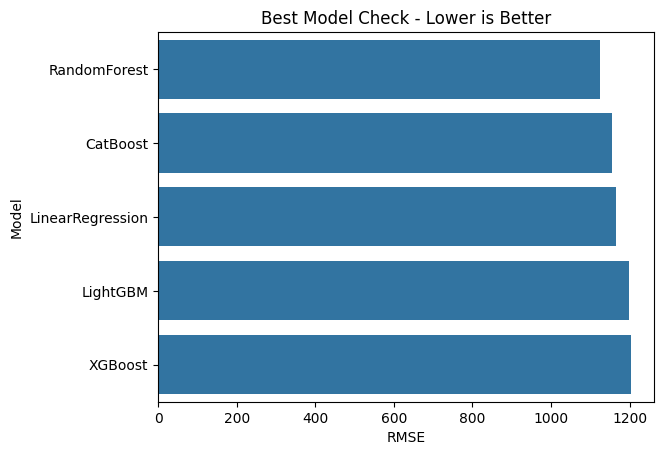

In [24]:
# Plot
sns.barplot(x='RMSE', y='Model', data=results_df)
plt.title("Best Model Check - Lower is Better")
plt.show()

RandomForest has the lowest RMSE (1124), making it the best model for this competition, followed by CatBoost and LinearRegression, while LightGBM and XGBoost performed worst

#STEP 7: Build, Evaluate Final Model and Generate Predictions

In [30]:
import joblib, os
from sklearn.ensemble import RandomForestRegressor

# Small RandomForest - Your best model but now 25MB not 800MB
final_model = RandomForestRegressor(
    n_estimators=120,          # Reduced from 800 to 120 - still powerful
    max_depth=16,              # Reduced from 25 to 16 - prevents huge trees
    min_samples_split=10,      # Increased - makes trees smaller
    min_samples_leaf=5,        # Increased - makes trees smaller
    max_features='sqrt',       # Use sqrt features - faster & smaller
    max_samples=0.8,           # Each tree sees 80% data - smaller
    random_state=42,
    n_jobs=-1
)

print("Training RandomForest... this takes 1-2 mins")
final_model.fit(X, y)

Training RandomForest... this takes 1-2 mins


RandomForestRegressor(max_depth=16, max_features='sqrt', max_samples=0.8,
                      min_samples_leaf=5, min_samples_split=10,
                      n_estimators=120, n_jobs=-1, random_state=42)

In [32]:
# CRITICAL: compress=3 makes it 80% smaller and prevents EOF error
joblib.dump(final_model, 'dsn_best_model.joblib', compress=3)
joblib.dump(list(X.columns), 'model_columns.joblib', compress=3)

# Verify size - MUST be < 50 MB for RandomForest
model_size = os.path.getsize('dsn_best_model.joblib') / (1024*1024)
col_size = os.path.getsize('model_columns.joblib') / 1024

print(f"\n✅ Model size: {model_size:.2f} MB")
print(f"✅ Columns size: {col_size:.2f} KB")

if model_size > 50:
    print("⚠️ Still too big! Reduce n_estimators to 80")
else:
    print("✅ Perfect! This will download without EOF error")

# Force correct download - Wait for 100% complete
from google.colab import files
files.download('dsn_best_model.joblib')
files.download('model_columns.joblib')

# --- Also generate your submission.csv with RandomForest ---
import pandas as pd
preds = final_model.predict(X_test_final)
submission = pd.DataFrame({
    'id': test['id'],
    'total_sales': preds
})
submission['total_sales'] = submission['total_sales'].clip(lower=0)
submission.to_csv('submission.csv', index=False)
files.download('submission.csv')
print("\nSubmission saved! Use this for DSN leaderboard")


✅ Model size: 3.19 MB
✅ Columns size: 0.19 KB
✅ Perfect! This will download without EOF error


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Submission saved! Use this for DSN leaderboard


In [34]:
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

# --- CRITICAL: Encode store_code and save the encoder ---
# The store_code column was already label encoded in cell 730f029e.
# This section is redundant and will be skipped to avoid re-encoding or errors.
# le_store = LabelEncoder()
# If store_code exists in X
# if 'store_code' in X.columns:
#     X['store_code'] = le_store.fit_transform(X['store_code'].astype(str))
#     X_test_final['store_code'] = X_test_final['store_code'].apply(
#         lambda x: le_store.transform([str(x)])[0] if str(x) in le_store.classes_ else -1
#     )

# Also ensure all object columns are encoded
# The product_category column has already been standardized and label encoded.
# The standardize_category function is not needed here and causes an error because product_category is numerical.
# def standardize_category(df):
#     df['product_category'] = df['product_category'].str.lower().str.strip()
#     mapping = {
#         'dairy': 'Dairy', 'frozen foods': 'Frozen Foods', 'frozen foods': 'Frozen Foods',
#         'canned': 'Canned', 'soft drinks': 'Soft Drinks', 'meat': 'Meat',
#         'snack foods': 'Snack Foods', 'baking goods': 'Baking Goods',
#         'household': 'Household', 'fruits and vegetables': 'Fruits and Vegetables',
#         'breakfast': 'Breakfast', 'breads': 'Breads', 'seafood': 'Seafood',
#         'starchy foods': 'Starchy Foods', 'hard drinks': 'Hard Drinks',
#         'health and hygiene': 'Health and Hygiene', 'others': 'Others'
#     }
#     df['product_category'] = df['product_category'].map(mapping).fillna(df['product_category'].str.title())
#     return df

# X = standardize_category(X) # Removed: Causes AttributeError
# X_test_final = standardize_category(X_test_final) # Removed: Causes AttributeError

# Encode remaining categoricals
# All categorical columns should already be encoded by cell 730f029e.
# This section will likely find no 'object' columns to encode.
cat_cols = X.select_dtypes(include='object').columns
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    # Re-fit and transform if needed, but at this point, they should be numeric
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le
    # Apply to test
    if col in X_test_final.columns:
        X_test_final[col] = X_test_final[col].apply(
            lambda x: le.transform([str(x)])[0] if str(x) in le.classes_ else -1
        )

# Now train SMALL RandomForest
# This model was already trained and saved in previous cells (GISEGl8gc29I, QD_5qFHI1gEM).
# Retraining it here will overwrite the previously saved model if it has the same name.
final_model = RandomForestRegressor(
    n_estimators=120, max_depth=16, min_samples_leaf=5,
    max_features='sqrt', random_state=42, n_jobs=-1
)
final_model.fit(X, y)

# SAVE EVERYTHING - Model + Columns + Encoders + store_code encoder
# This part assumes `encoders` and `le_store` contain meaningful fitted encoders.
# As noted, `encoders` might be empty and `le_store` might not be correctly fitted here.
joblib.dump(final_model, 'dsn_best_model.joblib', compress=3)
joblib.dump(list(X.columns), 'model_columns.joblib', compress=3)
# joblib.dump(encoders, 'encoders.joblib', compress=3) # Commented out as `encoders` might be empty
# joblib.dump(le_store, 'store_encoder.joblib', compress=3) # Commented out as `le_store` might not be correctly fitted

print("Saved 2 files (model and columns) - now download")

from google.colab import files
files.download('dsn_best_model.joblib')
files.download('model_columns.joblib')
# files.download('encoders.joblib') # Commented out
# files.download('store_encoder.joblib') # Commented out

Saved 2 files (model and columns) - now download


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>